In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [4]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
print(X_train.shape, y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(60000, 28, 28) (60000,)


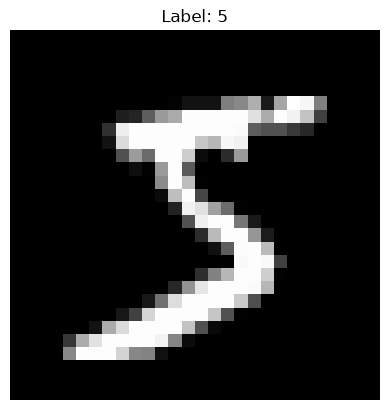

In [5]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [13]:
X_train=X_train/255.0
X_test=X_test/255.0
model=keras.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])


In [12]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(X_train, y_train, epochs=5)
model.evaluate(X_test, y_test)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.8945 - loss: 0.3851
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9036 - loss: 0.3434
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9087 - loss: 0.3197
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9130 - loss: 0.3035
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9166 - loss: 0.2910
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9198 - loss: 0.2760


[0.27599775791168213, 0.9197999835014343]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
[9.2562957e-11 2.2018351e-12 1.1490763e-07 5.2747005e-06 9.6083140e-15
 7.7633022e-12 1.3607993e-17 9.9999440e-01 4.6116986e-09 2.4421783e-07]
7


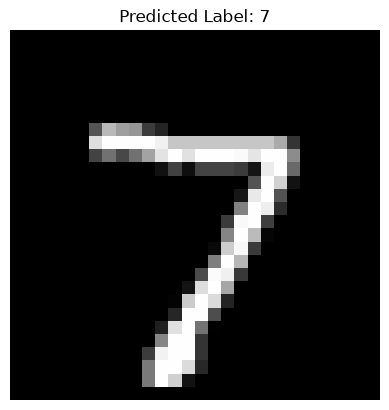

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9774 - loss: 0.0819


[0.08186040818691254, 0.977400004863739]

In [10]:
predictions=model.predict(X_test)
print(predictions[0])
print(np.argmax(predictions[0]))
plt.imshow(X_test[0], cmap="gray")
plt.title(f"Predicted Label: {np.argmax(predictions[0])}")
plt.axis("off")
plt.show()  
model.save("mnist_model.h5")
new_model=keras.models.load_model("mnist_model.h5")
new_model.evaluate(X_test, y_test)